In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix

In [5]:
df = sns.load_dataset("iris")

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [33]:
df = df[["sepal_length", "petal_length", "species"]]
df.sample(5)

,sepal_length,petal_length,species
98,5.1,3.0,1
26,5.0,1.6,0
24,4.8,1.9,0
79,5.7,3.5,1
137,6.4,5.5,2


In [10]:
encoder = LabelEncoder()
df["species"] = encoder.fit_transform(df["species"])

In [32]:
df.sample()

,sepal_length,petal_length,species
69,5.6,3.9,1


In [12]:
X = df.drop(columns=["species"])
y = df["species"]

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4
...,...,...
145,6.7,5.2
146,6.3,5.0
147,6.5,5.2
148,6.2,5.4


In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [17]:
clf = LogisticRegression()
clf.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9666666666666667

In [25]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [31]:
query = pd.DataFrame({
    "sepal_length" : [3.4], "petal_length" : [2.7]
})
clf.predict(query)

array([0])

C:\conda\anaconda3\envs\DSenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


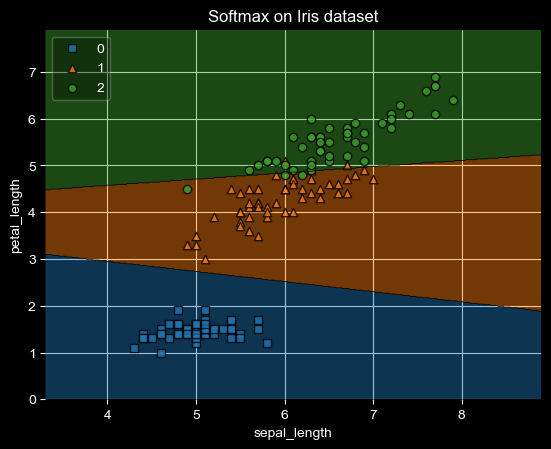

In [37]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

plt.xlabel("sepal_length")
plt.ylabel("petal_length")
plt.title("Softmax on Iris dataset")
plt.show()